# BSCL Registration: C5-HC-4w → C6_Tr_4w

Регистрация двух реальных конфокальных серий из папки `data/BSCL`:

| Образец | Папка | Слайсов | Разрешение |
|---------|-------|---------|------------|
| Moving | `C5-HC-4w/Pattern 1` | 465 | 1472 × 2184, uint16 |
| Fixed  | `C6_Tr_4w/Pattern 1` | 497 | 1472 × 2184, uint16 |

Стратегия:
- Загружаем с `scale=8` (~11 MB) для SA-стадий
- Финальное уточнение GD на `scale=4` (~90 MB)
- `ratio` = отношение XY/Z разрешения микроскопа (по умолчанию 1.0)

In [1]:
# pip install -e ".[io]"  ← один раз в окружении
import torch
import matplotlib.pyplot as plt
from IPython.display import clear_output

from brain_morph.utils import Volume, MeshTransformer3D
from brain_morph.registration import (
    registration_cost,
    Stage, RegistrationPipeline,
    SAOptimizer, GradientOptimizer,
)

print(f'torch {torch.__version__}  |  device: {"cuda" if torch.cuda.is_available() else "cpu"}')


torch 2.9.0  |  device: cpu


## 1. Пути к данным

In [2]:
BSCL_DIR = os.path.join(ROOT, 'data', 'BSCL')

MOVING_MASK = os.path.join(BSCL_DIR, 'C5-HC-4w',  'Pattern 1', 'Plane*.tif')
FIXED_MASK  = os.path.join(BSCL_DIR, 'C6_Tr_4w',  'Pattern 1', 'Plane*.tif')

OUTPUT_DIR  = os.path.join(ROOT, 'data', 'BSCL', 'results')
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Параметры загрузки ──────────────────────────────────────────────────────
SCALE_COARSE = 8     # уменьшение XY для SA-стадий: 1472→184, 2184→273
RATIO        = 1.6   # XY/Z разрешение; если Z-шаг вдвое крупнее XY → ratio=0.5

print(f'Moving: {MOVING_MASK}')
print(f'Fixed:  {FIXED_MASK}')

Moving: /Users/air/Yandex.Disk.localized/IADoronin_from_Google/DL_engineer/brain morph/data/BSCL/C5-HC-4w/Pattern 1/Plane*.tif
Fixed:  /Users/air/Yandex.Disk.localized/IADoronin_from_Google/DL_engineer/brain morph/data/BSCL/C6_Tr_4w/Pattern 1/Plane*.tif


## 2. Загрузка образцов

In [3]:
print('Загрузка moving (C5-HC-4w) ...')
vol_moving = Volume.load_tiff_series(MOVING_MASK, scale=SCALE_COARSE, ratio=RATIO)
print(f'  moving: {tuple(vol_moving.shape)}  dtype={vol_moving.dtype}')

print('Загрузка fixed (C6_Tr_4w) ...')
vol_fixed = Volume.load_tiff_series(FIXED_MASK, scale=SCALE_COARSE, ratio=RATIO)
print(f'  fixed:  {tuple(vol_fixed.shape)}  dtype={vol_fixed.dtype}')

# Нормализовать в [0, 1] float32, оставить форму (1, D, H, W)
def norm_vol(v: Volume) -> Volume:
    t = v.float()
    return (t / t.max().clamp_min(1e-6)).as_subclass(Volume)

vol_moving = norm_vol(vol_moving)
vol_fixed  = norm_vol(vol_fixed)

# Обрезать fixed по D до размера moving (разное число слайсов)
D = vol_moving.shape[1]
vol_fixed = vol_fixed[:, :D].as_subclass(Volume)

# (1, D, H, W) — для регистрации и visualize
im_moving = vol_moving   # Volume (1, D, H, W)
im_fixed  = vol_fixed    # Volume (1, D, H, W)

H, W = im_moving.shape[2], im_moving.shape[3]
print(f'\nim_moving: {tuple(im_moving.shape)}  im_fixed: {tuple(im_fixed.shape)}')

Загрузка moving (C5-HC-4w) ...
  moving: (1, 93, 184, 273)  dtype=torch.float32
Загрузка fixed (C6_Tr_4w) ...
  fixed:  (1, 100, 184, 273)  dtype=torch.float32

im_moving: (1, 93, 184, 273)  im_fixed: (1, 93, 184, 273)


## 3. Предварительный просмотр

=== Moving: C5-HC-4w ===


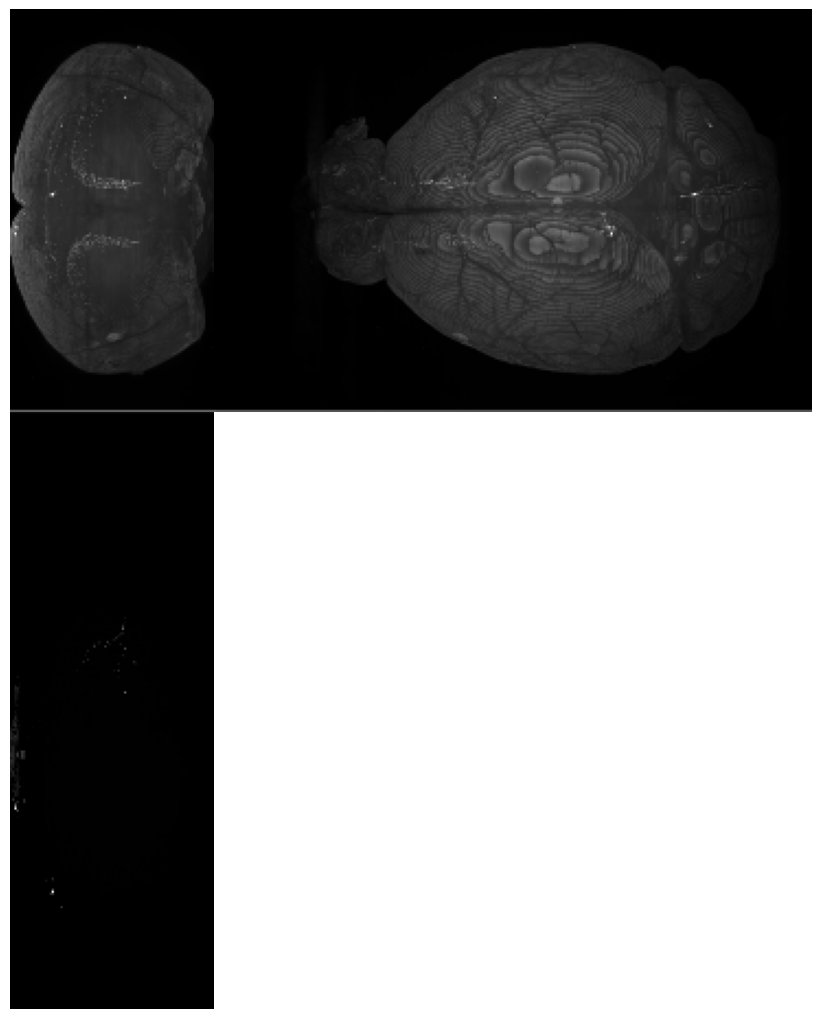

In [4]:
print('=== Moving: C5-HC-4w ===')
im_moving.visualize(channel=0)

=== Fixed: C6_Tr_4w (обрезанный) ===


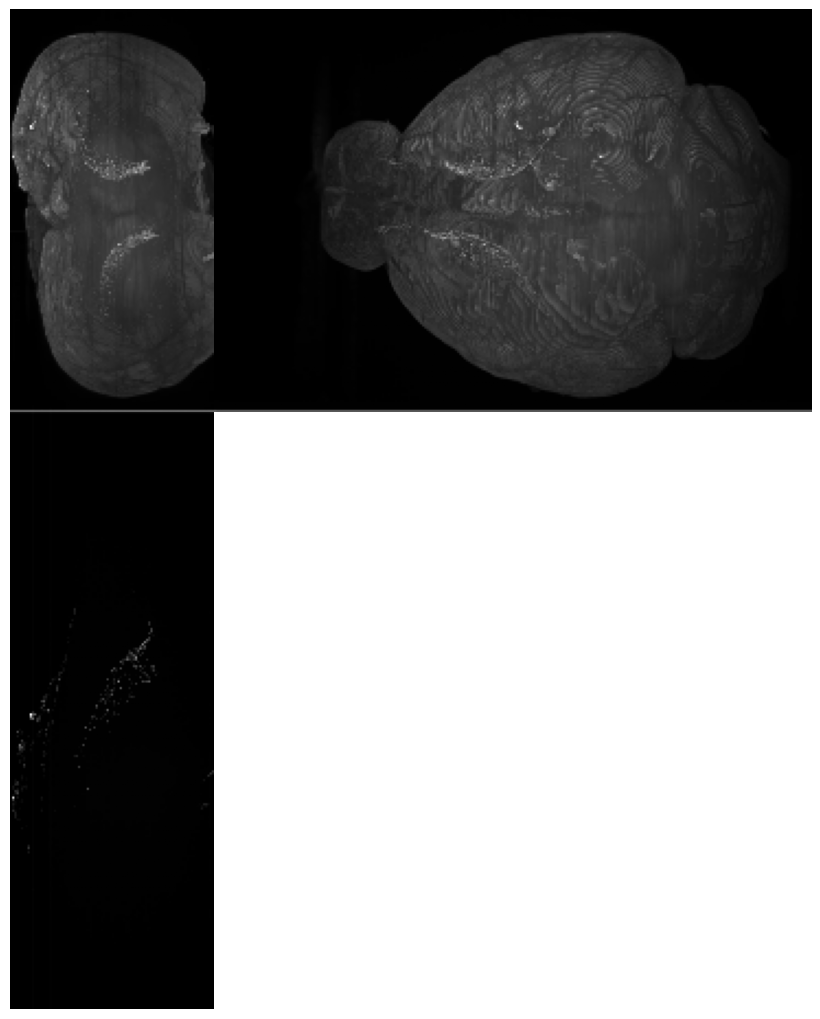

In [5]:
print('=== Fixed: C6_Tr_4w (обрезанный) ===')
im_fixed.visualize(channel=0)

## 4. Baseline: identity

NCC (identity): 0.7887
=== |moving − fixed| до регистрации ===


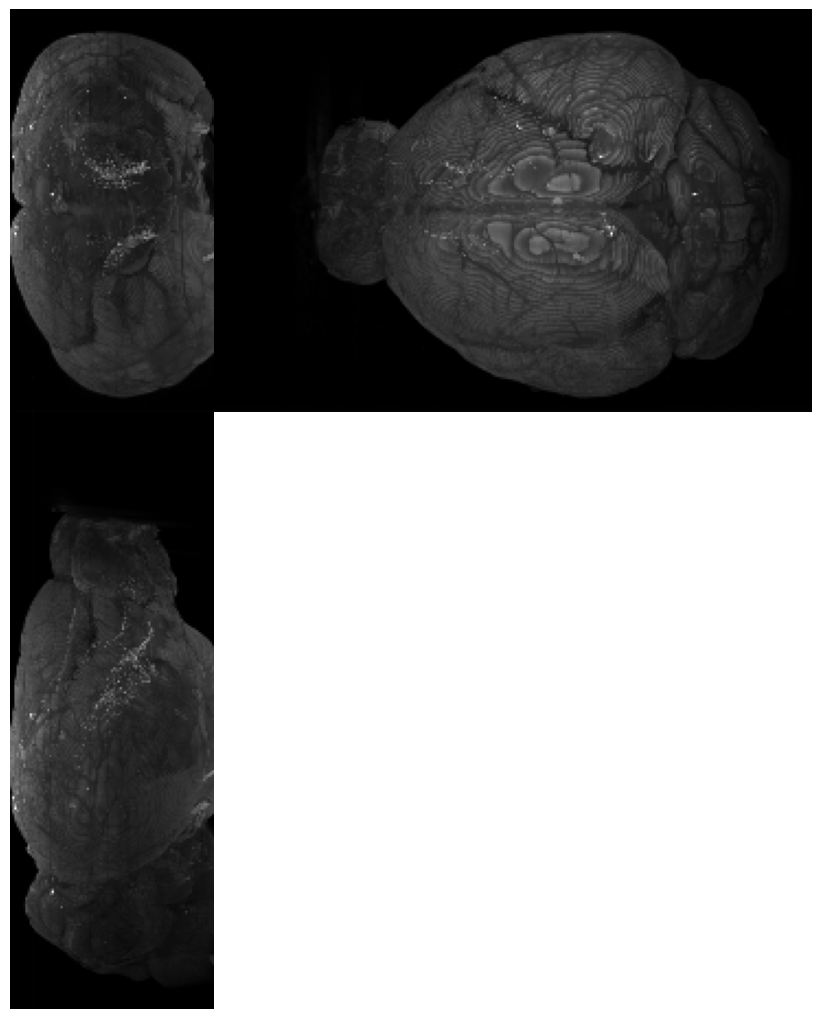

In [6]:
grid_init = torch.stack(
    torch.meshgrid(*[torch.linspace(-1, 1, s) for s in (4, 4, 4)], indexing='ij'),
    dim=-1,
)
# transform ожидает (C, D, H, W) → возвращает (C, D, H, W)
t_base = MeshTransformer3D(grid_init, (D, H, W))

with torch.no_grad():
    warped_id = t_base.transform(im_moving, grid_init)   # (1, D, H, W)

cost_id = registration_cost(
    im_moving, im_fixed, t_base, grid_init, lam=0, similarity='ncc'
).item()
print(f'NCC (identity): {cost_id:.4f}')

print('=== |moving − fixed| до регистрации ===')
Volume((warped_id - im_fixed).abs()).visualize(channel=0)

## 5. Настройка пайплайна

| Стадия | Сетка | Шагов | λ | Scale |
|--------|-------|-------|---|-------|
| SA-1 (грубая) | 2×2×2 | 2000 | 5e-2 | ×8 |
| SA-2 | 4×4×3 | 2000 | 2e-2 | ×8 |
| SA-3 | 5×5×4 | 2000 | 1e-2 | ×4 |
| GD-refine | 5×5×4 | 400  | 2e-3 | ×1 |

In [ ]:
cost_log = []

def _live_cb(step, cost, warped):
    cost_log.append((step, cost))
    clear_output(wait=True)
    print(f'step {step:5d}  |  NCC = {cost:.5f}')

    # warped приходит на масштабе текущей стадии — приводим к полному размеру
    w = warped if warped.dim() == 4 else warped.unsqueeze(0)   # (C, D', H', W')
    if tuple(w.shape[1:]) != (D, H, W):
        w = torch.nn.functional.interpolate(
            w.float().unsqueeze(0), size=(D, H, W),
            mode='trilinear', align_corners=False,
        ).squeeze(0)                                            # (1, D, H, W)

    ch    = w[0]              # (D, H, W)
    fx    = im_fixed[0]       # (D, H, W)
    diff  = (ch - fx).abs()

    fig, axes = plt.subplots(2, 3, figsize=(12, 6))
    for col, (dim, lbl) in enumerate([(0, 'XY'), (1, 'XZ'), (2, 'YZ')]):
        axes[0, col].imshow(ch.amax(dim).cpu(),   cmap='gray', vmin=0, vmax=1)
        axes[0, col].set_title(f'warped {lbl}'); axes[0, col].axis('off')
        axes[1, col].imshow(diff.amax(dim).cpu(), cmap='hot',  vmin=0, vmax=0.5)
        axes[1, col].set_title(f'|diff| {lbl}');  axes[1, col].axis('off')
    plt.tight_layout()
    plt.show()

    if len(cost_log) > 1:
        steps_, costs_ = zip(*cost_log)
        fig2, ax2 = plt.subplots(figsize=(9, 2))
        ax2.plot(steps_, costs_, lw=1, color='tab:blue')
        ax2.set_xlabel('step'); ax2.set_ylabel('NCC')
        plt.tight_layout()
        plt.show()


_sa_kw = dict(
    coeff_start=0.12, coeff_drop=0.9966,
    attention_freq=50,
    callback=_live_cb, callback_freq=200,
    similarity='ncc',
)

sa_1 = SAOptimizer(temp_start=2e-3, temp_end=2e-5, **_sa_kw)
sa_2 = SAOptimizer(temp_start=1e-3, temp_end=1e-5, **_sa_kw)
sa_3 = SAOptimizer(temp_start=5e-4, temp_end=5e-6, **_sa_kw)
gd   = GradientOptimizer(
    optimizer_cls=torch.optim.Adam, lr=5e-4,
    tension_mode='squared', similarity='ncc',
)

pipeline = RegistrationPipeline([
    Stage(grid_shape=(2, 2, 2), optimizer=sa_1, n_steps=2000, lam=5e-2, image_scale=8),
    Stage(grid_shape=(4, 4, 3), optimizer=sa_2, n_steps=2000, lam=2e-2, image_scale=8),
    Stage(grid_shape=(5, 5, 4), optimizer=sa_3, n_steps=2000, lam=1e-2, image_scale=4),
    Stage(grid_shape=(5, 5, 4), optimizer=gd,   n_steps=400,  lam=2e-3, image_scale=1),
])
print('Пайплайн готов.')

## 6. Запуск регистрации

In [8]:
cost_log.clear()
grid_result = pipeline.run(im_moving, im_fixed)
clear_output(wait=True)
print(f'Готово. Итоговая сетка: {grid_result.shape}')

step     0  |  NCC = 0.83183


RuntimeError: The size of tensor a (34) must match the size of tensor b (273) at non-singleton dimension 3

## 7. Результат

In [ ]:
grid_init_final = torch.stack(
    torch.meshgrid(*[torch.linspace(-1, 1, s) for s in grid_result.shape[:3]], indexing='ij'),
    dim=-1,
)
t_final = MeshTransformer3D(grid_init_final, (D, H, W))

with torch.no_grad():
    warped_result = t_final.transform(im_moving, grid_result)

cost_result = registration_cost(
    im_moving, im_fixed, t_final, grid_result, lam=0, similarity='ncc'
).item()

print(f'NCC identity: {cost_id:.4f}')
print(f'NCC result:   {cost_result:.4f}  (Δ = {cost_result - cost_id:+.4f})')

print('=== Warped moving ===')
Volume(warped_result.unsqueeze(0)).visualize(channel=0)

print('=== |warped − fixed| ===')
Volume((warped_result - im_fixed).abs().unsqueeze(0)).visualize(channel=0)

## 8. Сравнение до/после

In [ ]:
diff_before = (warped_id     - im_fixed).abs()
diff_after  = (warped_result - im_fixed).abs()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
vmax = max(diff_before.amax().item(), diff_after.amax().item())
axes[0].imshow(diff_before.amax(0).cpu(), cmap='hot', vmin=0, vmax=vmax)
axes[0].set_title(f'|diff| до  (XY max-proj)\nNCC={cost_id:.3f}'); axes[0].axis('off')
axes[1].imshow(diff_after.amax(0).cpu(),  cmap='hot', vmin=0, vmax=vmax)
axes[1].set_title(f'|diff| после  (XY max-proj)\nNCC={cost_result:.3f}'); axes[1].axis('off')
plt.tight_layout(); plt.show()

## 9. График метрики

In [ ]:
if cost_log:
    steps, costs = zip(*cost_log)
    fig, ax = plt.subplots(figsize=(10, 3))
    ax.plot(steps, costs, lw=1.2, color='tab:blue')
    ax.set_xlabel('SA step'); ax.set_ylabel('NCC − λ·tension')
    ax.set_title('Registration cost по стадиям')
    for i in range(1, len(steps)):
        if steps[i] < steps[i-1]:
            ax.axvline(steps[i], color='gray', ls='--', lw=0.8)
    plt.tight_layout(); plt.show()

## 10. Сохранение результата

In [ ]:
import nibabel as nib
import numpy as np

out_nii  = os.path.join(OUTPUT_DIR, 'C5_warped_to_C6.nii.gz')
out_grid = os.path.join(OUTPUT_DIR, 'C5_to_C6_grid.pt')

arr = warped_result.cpu().numpy().astype(np.float32)
nib.save(nib.Nifti1Image(arr, affine=np.eye(4)), out_nii)
torch.save(grid_result, out_grid)

print(f'NIfTI сохранён:  {out_nii}')
print(f'Сетка сохранена: {out_grid}')

## Приложение: повторное применение сетки

In [ ]:
# grid_saved = torch.load(out_grid)
# grid_init_s = torch.stack(
#     torch.meshgrid(*[torch.linspace(-1, 1, s) for s in grid_saved.shape[:3]], indexing='ij'),
#     dim=-1,
# )
# t_saved = MeshTransformer3D(grid_init_s, im_moving.shape)
# with torch.no_grad():
#     warped_new = t_saved.transform(another_volume, grid_saved)